# Study how calorimeter decay shower truth is processed

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("../")
from pyedm4hep import EDM4hepEvent

## Roadmap

1. Load in keep_all, low_threshold, medium_threshold events
2. Find particle that is: [greater than 0.001 GeV, created inside tracker, left a hit] which is in the low_threshold event but not the keep_all event
3. Get its ancestors and descendants in the keep_all event
4. Print the decay chain back to the pion in the keep_all event
5. Understand if there was ANY behaviour that may have led it to being dropped in the medium threshold event


# Single Particle - No Energy Threshold

In [2]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [3]:
base_dir = "/global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests/"
event_num = 0

This is with the TC truth handler turned on, but with a tracker the size of the world volume. That is, we should see energy threshold effects, but not calorimeter decay collapse effects.

In [4]:
edm4hep_file = f"{base_dir}/single_run_test_ODD_low_threshold/edm4hep.root"
low_event = EDM4hepEvent(edm4hep_file, event_index=event_num, detector_params=detector_params)

Loading event 0 from /global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests//single_run_test_ODD_low_threshold/edm4hep.root...
  Loaded 542 particles.
  Loaded 29 tracker hits.
  Loaded 631 calo hits and 2220 contributions.


In [5]:
edm4hep_file = f"{base_dir}/single_run_test_ODD_medium_threshold/edm4hep.root"
medium_event = EDM4hepEvent(edm4hep_file, event_index=event_num, detector_params=detector_params)

Loading event 0 from /global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests//single_run_test_ODD_medium_threshold/edm4hep.root...
  Loaded 210 particles.
  Loaded 29 tracker hits.
  Loaded 631 calo hits and 2220 contributions.


In [6]:
edm4hep_file = f"{base_dir}/single_run_test_ODD_keep_all/edm4hep.root"
keepall_event = EDM4hepEvent(edm4hep_file, event_index=event_num, detector_params=detector_params)

Loading event 0 from /global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests//single_run_test_ODD_keep_all/edm4hep.root...
  Loaded 10776 particles.
  Loaded 29 tracker hits.
  Loaded 631 calo hits and 2220 contributions.


## Interrogating a Sample Particle

To diagnose the difference, we need to know:
- Take a particle produced in the tracker in low threshold that doesn't appear in high threshold, which is above 0.001 GeV

In [12]:
keepall_particles_df, keepall_daughters_df, keepall_parents_df = keepall_event["particles_df"], keepall_event["daughters_df"], keepall_event["parents_df"]
keepall_tracker_df, keepall_calo_hit_df, keepall_calo_contrib_df = keepall_event["tracker_df"], keepall_event["calo_hits_df"], keepall_event["calo_contrib_df"]

medium_particles_df, medium_daughters_df, medium_parents_df = medium_event["particles_df"], medium_event["daughters_df"], medium_event["parents_df"]
medium_tracker_df, medium_calo_hit_df, medium_calo_contrib_df = medium_event["tracker_df"], medium_event["calo_hits_df"], medium_event["calo_contrib_df"]

low_particles_df, low_daughters_df, low_parents_df = low_event["particles_df"], low_event["daughters_df"], low_event["parents_df"]
low_tracker_df, low_calo_hit_df, low_calo_contrib_df = low_event["tracker_df"], low_event["calo_hits_df"], low_event["calo_contrib_df"]

In [22]:
low_sample = 17

In [25]:
keepall_sample = keepall_particles_df[(keepall_particles_df.time == low_particles_df.loc[low_sample].time) & (keepall_particles_df.p == low_particles_df.loc[low_sample].p)].index[0]
medium_sample = medium_particles_df[(medium_particles_df.time == low_particles_df.loc[low_sample].time) & (medium_particles_df.p == low_particles_df.loc[low_sample].p)].index[0]

In [16]:
keepall_G = build_decay_tree(keepall_particles_df, keepall_daughters_df)
print(f"Built graph with {keepall_G.number_of_nodes()} nodes and {keepall_G.number_of_edges()} edges")

medium_G = build_decay_tree(medium_particles_df, medium_daughters_df)
print(f"Built graph with {medium_G.number_of_nodes()} nodes and {medium_G.number_of_edges()} edges")

low_G = build_decay_tree(low_particles_df, low_daughters_df)
print(f"Built graph with {low_G.number_of_nodes()} nodes and {low_G.number_of_edges()} edges")

Creating nodes...
Created 10775 edges
Built graph with 10776 nodes and 10775 edges
Creating nodes...
Created 209 edges
Built graph with 210 nodes and 209 edges
Creating nodes...
Created 541 edges
Built graph with 542 nodes and 541 edges


In [20]:
keepall_sample

np.int64(21)

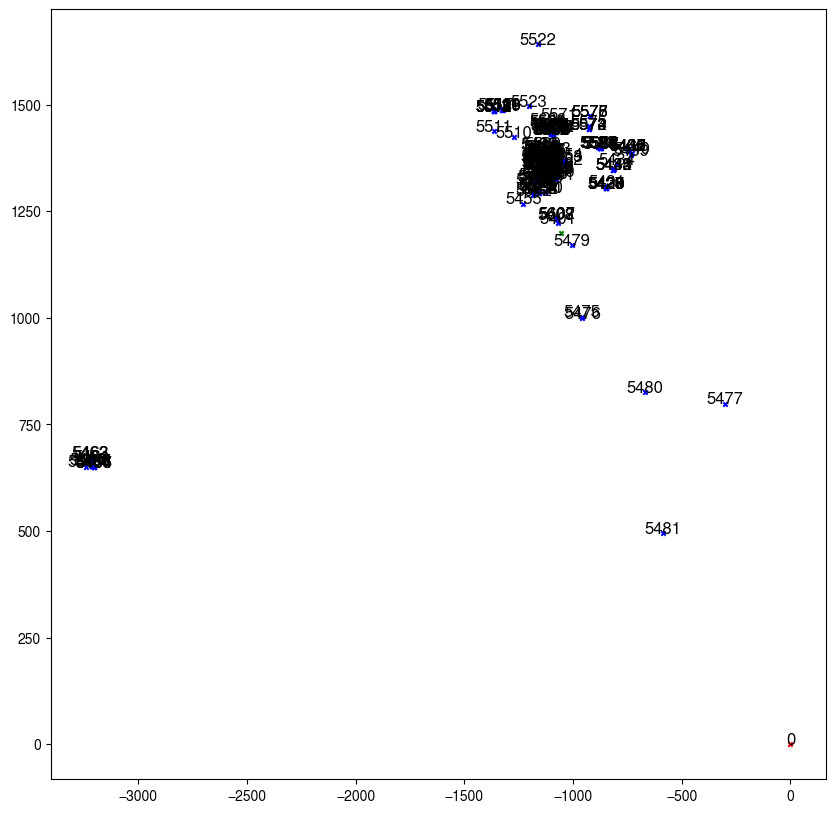

In [21]:
keepall_ancestors = list(nx.ancestors(keepall_G, keepall_sample))
keepall_descendants = list(nx.descendants(keepall_G, keepall_sample))

plt.figure(figsize=(10, 10))
plt.scatter(keepall_particles_df.loc[keepall_ancestors].vz, keepall_particles_df.loc[keepall_ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(keepall_particles_df.loc[keepall_descendants].vz, keepall_particles_df.loc[keepall_descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(keepall_particles_df.loc[keepall_sample].vz, keepall_particles_df.loc[keepall_sample].vr, c="green", s=10, marker="x", label="Sample particle")

for ancestor in keepall_ancestors:
    plt.text(keepall_particles_df.loc[ancestor].vz, keepall_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in keepall_descendants:
    plt.text(keepall_particles_df.loc[descendant].vz, keepall_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')



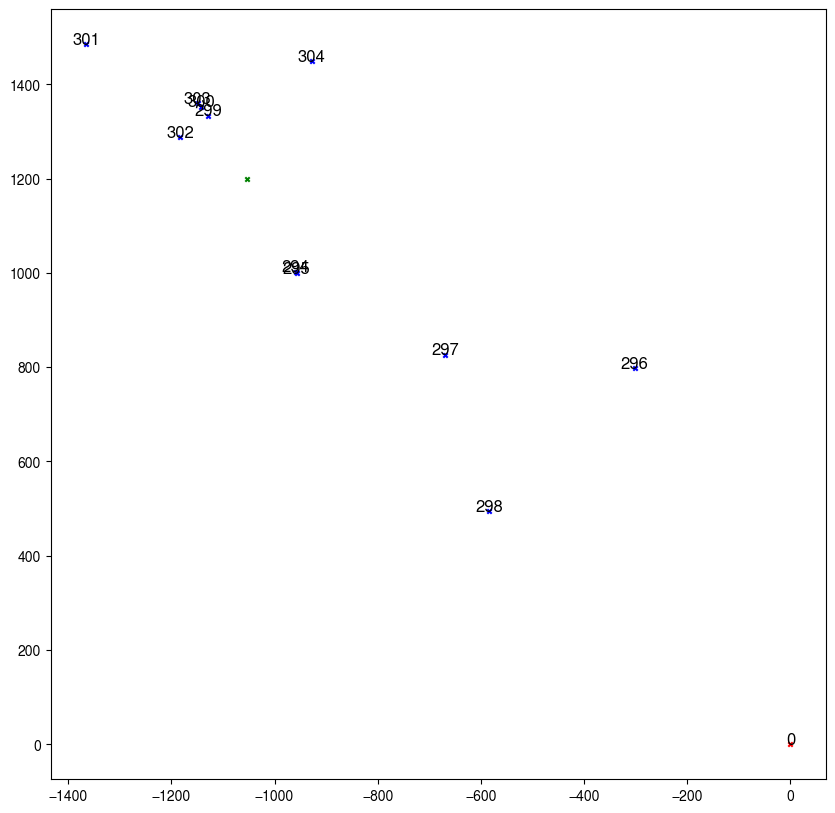

In [24]:
low_ancestors = list(nx.ancestors(low_G, low_sample))
low_descendants = list(nx.descendants(low_G, low_sample))

plt.figure(figsize=(10, 10))
plt.scatter(low_particles_df.loc[low_ancestors].vz, low_particles_df.loc[low_ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(low_particles_df.loc[low_descendants].vz, low_particles_df.loc[low_descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(low_particles_df.loc[low_sample].vz, low_particles_df.loc[low_sample].vr, c="green", s=10, marker="x", label="Sample particle")

for ancestor in low_ancestors:
    plt.text(low_particles_df.loc[ancestor].vz, low_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in low_descendants:
    plt.text(low_particles_df.loc[descendant].vz, low_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')



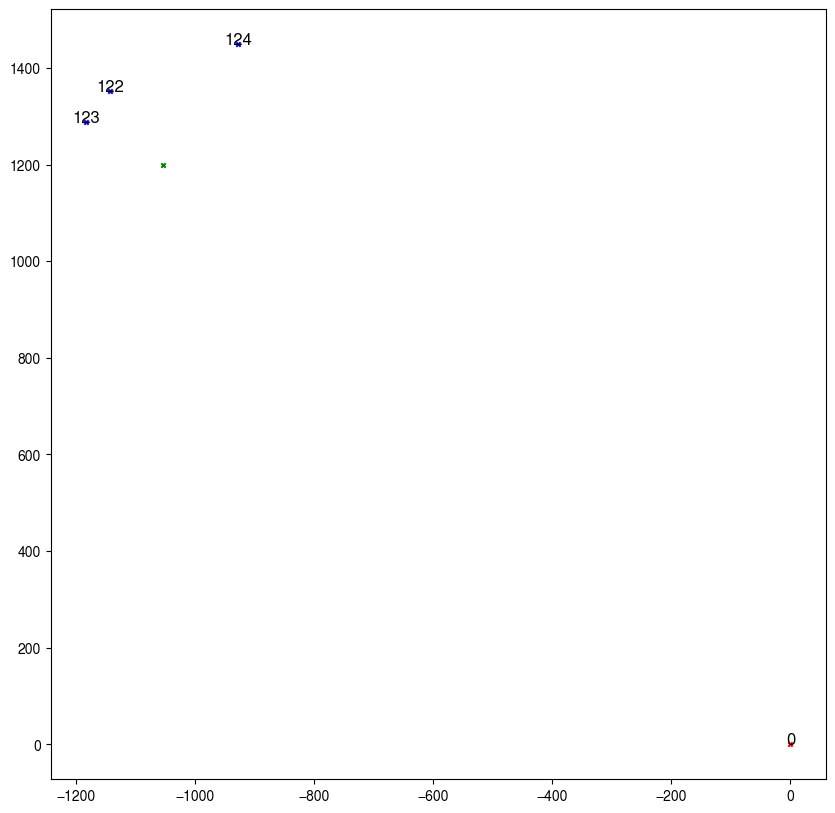

In [26]:
medium_ancestors = list(nx.ancestors(medium_G, medium_sample))
medium_descendants = list(nx.descendants(medium_G, medium_sample))

plt.figure(figsize=(10, 10))
plt.scatter(medium_particles_df.loc[medium_ancestors].vz, medium_particles_df.loc[medium_ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(medium_particles_df.loc[medium_descendants].vz, medium_particles_df.loc[medium_descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(medium_particles_df.loc[medium_sample].vz, medium_particles_df.loc[medium_sample].vr, c="green", s=10, marker="x", label="Sample particle")

for ancestor in medium_ancestors:
    plt.text(medium_particles_df.loc[ancestor].vz, medium_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in medium_descendants:
    plt.text(medium_particles_df.loc[descendant].vz, medium_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')



In [33]:
ODD_particles_df[(ODD_particles_df.created_inside_tracker == 1) & (ODD_particles_df.p > 0.001) & (ODD_particles_df.index.isin(ODD_tracker_hits_df.particle_id))]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,7.509689,10.000000,-0.793412,0.228517,0.000000,1198.486097,0,1,0,False
24,11,0,1493172224,-1.0,4671.243164,0.000511,887.201488,-226.843413,-1609.568058,-0.001318,...,0.001675,0.001865,0.471396,-2.476157,915.742548,915.024852,1,1,1,False
52,11,0,1493172224,-1.0,9.227405,0.000511,314.501088,584.036079,-1066.465255,-0.001554,...,0.001740,0.001870,0.383977,2.675096,663.331800,662.264360,1,1,1,False
184,1000140280,0,1493172224,14.0,120.285950,26.053194,160.881786,-799.384374,-484.063377,-0.090028,...,0.090222,0.096420,0.368570,3.076014,815.412979,815.412906,1,1,1,False
344,11,0,1493172224,-1.0,18.112108,0.000511,-180.292770,-716.912659,-1878.730636,-0.000665,...,0.001169,0.001210,-0.265605,-2.175534,739.235581,741.978114,1,1,1,False
413,1000140280,0,1493172224,14.0,79.946289,26.053194,-414.187350,712.111119,357.858223,-0.053050,...,0.053537,0.064229,0.621922,3.006580,823.804229,823.804284,1,1,1,False


In [41]:
ODD_particles_df[(ODD_particles_df.created_inside_tracker == 1) & (ODD_particles_df.p > 0.001)]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,7.509689,10.000000,-0.793412,0.228517,0.000000,1198.486097,0,1,0,False
10,11,0,1493172224,-1.0,2.822778,0.000511,622.399472,128.314568,-558.626150,0.002685,...,0.003212,0.003374,-0.316664,0.580828,635.488577,635.362217,1,1,1,False
22,1000060120,0,1493172224,6.0,82.184448,11.174863,779.981444,267.446657,-26.821603,-0.047077,...,0.047526,0.049225,-0.266636,-3.004059,824.559741,824.559120,1,1,1,False
24,11,0,1493172224,-1.0,4671.243164,0.000511,887.201488,-226.843413,-1609.568058,-0.001318,...,0.001675,0.001865,0.471396,-2.476157,915.742548,915.024852,1,1,1,False
25,2212,0,1493172224,1.0,53.086212,0.938272,954.525790,346.810214,108.060701,-0.027864,...,0.029728,0.029930,0.116326,-2.785515,1015.577081,1015.571365,1,1,1,False
26,2212,0,1493172224,1.0,56.786720,0.938272,954.524149,353.535477,128.394769,-0.006559,...,0.006592,0.015282,1.483760,-3.040772,1017.891785,1017.891148,1,1,1,False
33,2212,0,1493172224,1.0,150.397507,0.938272,144.944373,141.346661,-1840.468981,-0.008285,...,0.053781,0.056390,-0.310231,1.725463,202.454315,202.476218,1,1,1,False
34,2212,0,1493172224,1.0,161.036743,0.938272,86.421445,183.071480,-1894.598043,-0.013551,...,0.013662,0.022103,-1.061157,-3.014415,202.444642,202.443753,1,1,1,False
45,11,0,1493172224,-1.0,8.111740,0.000511,816.725718,75.020770,-696.730784,-0.001326,...,0.001362,0.001547,0.515469,-2.912612,820.164017,819.170412,1,1,1,False
52,11,0,1493172224,-1.0,9.227405,0.000511,314.501088,584.036079,-1066.465255,-0.001554,...,0.001740,0.001870,0.383977,2.675096,663.331800,662.264360,1,1,1,False


In [34]:
ODD_medium_particles_df[(ODD_medium_particles_df.created_inside_tracker == 1) & (ODD_medium_particles_df.p > 0.001) & (ODD_medium_particles_df.index.isin(ODD_medium_tracker_hits_df.particle_id))]


,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,7.509689,10.000000,-0.793412,0.228517,0.000000,1198.486097,0,1,0,False
9,11,0,1493172224,-1.0,4671.243164,0.000511,887.201488,-226.843413,-1609.568058,-0.001318,...,0.001675,0.001865,0.471396,-2.476157,915.742548,915.024852,1,1,1,False
23,11,0,1493172224,-1.0,9.227405,0.000511,314.501088,584.036079,-1066.465255,-0.001554,...,0.001740,0.001870,0.383977,2.675096,663.331800,662.264360,1,1,1,False
68,1000140280,0,1493172224,14.0,120.285950,26.053194,160.881786,-799.384374,-484.063377,-0.090028,...,0.090222,0.096420,0.368570,3.076014,815.412979,815.412906,1,1,1,False
137,11,0,1493172224,-1.0,18.112108,0.000511,-180.292770,-716.912659,-1878.730636,-0.000665,...,0.001169,0.001210,-0.265605,-2.175534,739.235581,741.978114,1,1,1,False
159,1000140280,0,1493172224,14.0,79.946289,26.053194,-414.187350,712.111119,357.858223,-0.053050,...,0.053537,0.064229,0.621922,3.006580,823.804229,823.804284,1,1,1,False


In [44]:
ODD_medium_particles_df[(ODD_medium_particles_df.created_inside_tracker == 1) & (ODD_medium_particles_df.pt > 0.001)]


,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,7.509689,10.000000,-0.793412,0.228517,0.000000,1198.486097,0,1,0,False
2,11,0,1493172224,-1.0,2.822778,0.000511,622.399472,128.314568,-558.626150,0.002685,...,0.003212,0.003374,-0.316664,0.580828,635.488577,635.362217,1,1,1,False
9,11,0,1493172224,-1.0,4671.243164,0.000511,887.201488,-226.843413,-1609.568058,-0.001318,...,0.001675,0.001865,0.471396,-2.476157,915.742548,915.024852,1,1,1,False
12,2212,0,1493172224,1.0,150.397507,0.938272,144.944373,141.346661,-1840.468981,-0.008285,...,0.053781,0.056390,-0.310231,1.725463,202.454315,202.476218,1,1,1,False
18,11,0,1493172224,-1.0,8.111740,0.000511,816.725718,75.020770,-696.730784,-0.001326,...,0.001362,0.001547,0.515469,-2.912612,820.164017,819.170412,1,1,1,False
23,11,0,1493172224,-1.0,9.227405,0.000511,314.501088,584.036079,-1066.465255,-0.001554,...,0.001740,0.001870,0.383977,2.675096,663.331800,662.264360,1,1,1,False
29,11,0,1493172224,-1.0,6.880608,0.000511,969.061636,314.895717,-1133.440404,-0.001720,...,0.001721,0.001748,0.176152,3.108573,1018.940511,1018.883078,1,1,1,False
68,1000140280,0,1493172224,14.0,120.285950,26.053194,160.881786,-799.384374,-484.063377,-0.090028,...,0.090222,0.096420,0.368570,3.076014,815.412979,815.412906,1,1,1,False
137,11,0,1493172224,-1.0,18.112108,0.000511,-180.292770,-716.912659,-1878.730636,-0.000665,...,0.001169,0.001210,-0.265605,-2.175534,739.235581,741.978114,1,1,1,False
157,22,0,1426063360,0.0,79.946289,0.000000,-414.187350,712.111119,357.858223,0.000338,...,0.001805,0.001860,0.247042,1.382467,823.804229,1317.000964,1,1,0,False


In [50]:
G

In [57]:
sample_particle = 17

In [56]:
full_particles_df.loc[17]

PDG                               211
generatorStatus                     0
simulatorStatus            1157627904
charge                            1.0
time                          5.32532
mass                          0.13957
vx                        1178.951708
vy                         215.503585
vz                       -1053.953215
px                           0.249553
py                           0.079074
pz                          -0.162467
endpoint_x                1336.337123
endpoint_y                 267.790471
endpoint_z               -1145.693797
parents_begin                      16
parents_end                        17
daughters_begin                   155
daughters_end                     165
pt                           0.261781
p                            0.308099
eta                         -0.586428
phi                          0.306855
vr                        1198.486097
endpoint_r                1362.904488
created_in_simulation               1
created_insi

In [72]:
sample_medium_particle = ODD_medium_particles_df[ODD_medium_particles_df.p == full_particles_df.loc[17].p]
sample_medium_particle


,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
5,211,0,1157627904,1.0,5.32532,0.13957,1178.951708,215.503585,-1053.953215,0.249553,...,0.261781,0.308099,-0.586428,0.306855,1198.486097,1362.904488,1,0,0,False


In [73]:
sample_medium_particle[["daughters_begin", "daughters_end"]]

,daughters_begin,daughters_end
5,61,64


In [85]:
ODD_medium_daughters_df.iloc[61:64]

,particle_id,collectionID
61,122,2714477136
62,123,2714477136
63,124,2714477136


In [87]:
ODD_medium_particles_df.iloc[122:125]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
122,11,0,1426063360,-1.0,341.038116,0.000511,1311.744785,330.314511,-1141.721344,-0.002753,...,0.003474,0.003481,0.062853,2.485515,1352.694370,1351.671725,1,0,0,False
123,11,0,1426063360,-1.0,9.123814,0.000511,1268.154626,222.749064,-1182.772404,-0.000440,...,0.001712,0.001893,-0.455684,-1.830751,1287.568756,1287.260273,1,0,0,False
124,11,0,1426063360,-1.0,347.468140,0.000511,1349.914344,526.744924,-928.061177,-0.000416,...,0.003037,0.003080,-0.167306,1.708255,1449.044151,1451.945232,1,0,0,False


In [103]:
ODD_particles_df.iloc[ODD_daughters_df.iloc[155:165].particle_id]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
294,1000060120,0,1493172224,6.0,33.828335,11.174863,964.649457,273.681849,-959.198402,-0.048281,...,0.055506,0.057333,-0.255873,2.625684,1002.721462,1002.720916,1,1,1,False
295,2212,0,1493172224,1.0,34.851292,0.938272,965.524845,258.320685,-957.264826,0.019342,...,0.028034,0.030574,-0.422599,-0.809381,999.483768,999.486445,1,1,1,False
296,2212,0,1493172224,1.0,148.128433,0.938272,363.949961,-710.695347,-302.311091,-0.016046,...,0.033899,0.035305,0.287044,-2.063875,798.465686,798.470713,1,1,1,False
297,2212,0,1493172224,1.0,52.442951,0.938272,802.316092,197.734062,-669.525182,-0.038026,...,0.039581,0.041000,0.266989,2.860396,826.323103,826.310979,1,1,1,False
298,2212,0,1493172224,1.0,139.401184,0.938272,357.071640,-341.750220,-584.690253,-0.015396,...,0.015410,0.015851,0.238650,3.099259,494.260426,494.254081,1,1,1,False
299,2112,0,1426063360,0.0,10.091825,0.939565,1311.763829,239.943220,-1129.426218,0.016644,...,0.020474,0.021225,-0.269975,-0.621638,1333.528062,1374.739796,1,0,0,False
301,2112,0,1409286144,0.0,38.049347,0.939565,1401.153129,491.775042,-1365.538120,0.016283,...,0.016354,0.029916,1.212268,-0.092667,1484.948748,1681.162671,1,0,0,False
302,11,0,1426063360,-1.0,9.123814,0.000511,1268.154626,222.749064,-1182.772404,-0.000440,...,0.001712,0.001893,-0.455684,-1.830751,1287.568756,1287.260273,1,0,0,False
303,2112,0,1426063360,0.0,6.206884,0.939565,1333.890963,268.753989,-1149.095338,0.009543,...,0.040008,0.043078,0.389308,1.329942,1360.696075,1340.833977,1,0,0,False
304,11,0,1426063360,-1.0,347.468140,0.000511,1349.914344,526.744924,-928.061177,-0.000416,...,0.003037,0.003080,-0.167306,1.708255,1449.044151,1451.945232,1,0,0,False


In [86]:
ODD_daughters_df.iloc[155:165]

,particle_id,collectionID,parent_id
155,294,2714477136,17
156,295,2714477136,17
157,296,2714477136,17
158,297,2714477136,17
159,298,2714477136,17
160,299,2714477136,17
161,301,2714477136,17
162,302,2714477136,17
163,303,2714477136,17
164,304,2714477136,17


In [93]:
ODD_medium_particles_df[ODD_medium_particles_df.p == ODD_particles_df.loc[295].p]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter


In [91]:
ODD_particles_df.loc[295]

PDG                             2212
generatorStatus                    0
simulatorStatus           1493172224
charge                           1.0
time                       34.851292
mass                        0.938272
vx                        965.524845
vy                        258.320685
vz                       -957.264826
px                          0.019342
py                         -0.020292
pz                         -0.012203
endpoint_x                965.528697
endpoint_y                258.316643
endpoint_z               -957.267256
parents_begin                    294
parents_end                      295
daughters_begin                  400
daughters_end                    400
pt                          0.028034
p                           0.030574
eta                        -0.422599
phi                        -0.809381
vr                        999.483768
endpoint_r                999.486445
created_in_simulation              1
created_inside_tracker             1
e

In [94]:
get_simulator_status_bits(ODD_particles_df.loc[295].simulatorStatus)

{'created_in_simulation': '1',
 'backscatter': '0',
 'vertex_not_endpoint': '1',
 'decayed_in_tracker': '1',
 'decayed_in_calorimeter': '0',
 'has_left_detector': '0',
 'stopped': '1',
 'overlay': '0'}

In [97]:
ODD_particles_df.iloc[294:305][["parents_begin", "parents_end"]]

,parents_begin,parents_end
294,293,294
295,294,295
296,295,296
297,296,297
298,297,298
299,298,299
300,299,300
301,300,301
302,301,302
303,302,303


In [101]:
full_parents_df.iloc[293:304]

,particle_id,collectionID
293,17,2714477136
294,17,2714477136
295,17,2714477136
296,17,2714477136
297,17,2714477136
298,17,2714477136
299,299,2714477136
300,17,2714477136
301,17,2714477136
302,17,2714477136


In [102]:
ODD_calo_hits_df[ODD_calo_hits_df.particle_id.isin(ODD_daughters_df.iloc[155:165].particle_id)]

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector
1016,0,3.097946e-05,10.337384,0.0,0.0,0.0,299,249,1313.000000,239.699997,-1132.199951,ECalBarrelCollection
1018,0,3.696365e-05,9.127080,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1019,0,1.948491e-05,9.127319,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1020,0,3.767398e-05,9.127589,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1021,0,3.723178e-05,9.127836,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1022,0,5.768460e-05,9.128127,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1023,0,1.195975e-05,9.128245,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1024,0,3.862598e-06,15.465124,0.0,0.0,0.0,303,252,1332.349365,320.028748,-1111.800049,ECalBarrelCollection
1025,0,1.532812e-04,347.471252,0.0,0.0,0.0,304,253,1350.734863,526.371521,-928.200012,ECalBarrelCollection
1026,0,5.899418e-05,347.471802,0.0,0.0,0.0,304,253,1350.734863,526.371521,-928.200012,ECalBarrelCollection


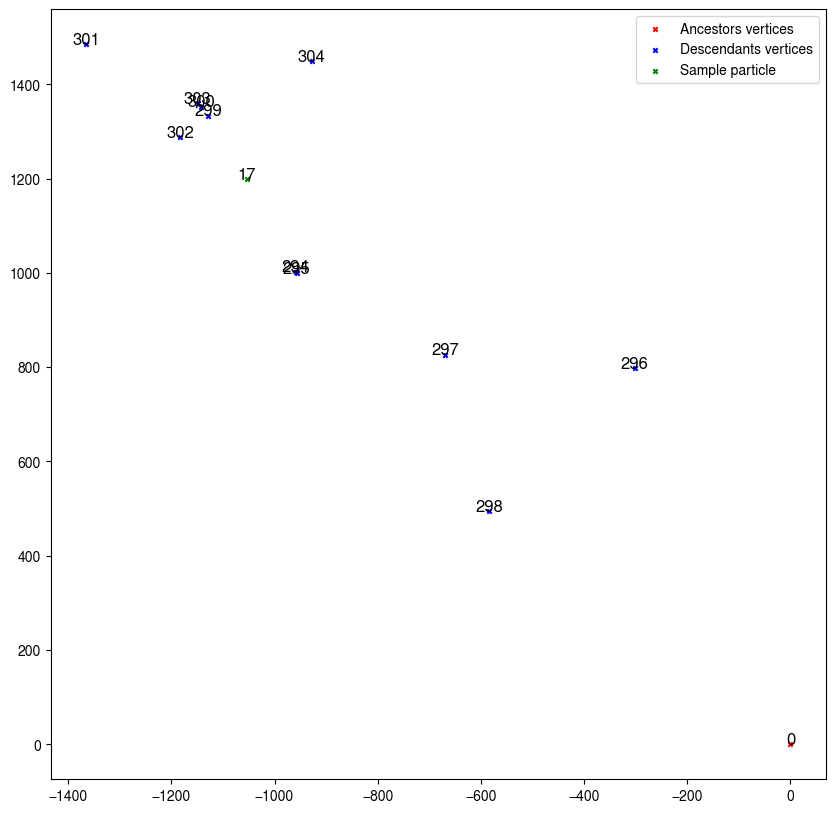

In [58]:
descendants = list(nx.descendants(G, sample_particle))
ancestors = list(nx.ancestors(G, sample_particle))

plt.figure(figsize=(10, 10))
plt.scatter(full_particles_df.loc[ancestors].vz, full_particles_df.loc[ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(full_particles_df.loc[descendants].vz, full_particles_df.loc[descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(full_particles_df.loc[sample_particle].vz, full_particles_df.loc[sample_particle].vr, c="green", s=10, marker="x", label="Sample particle")

# Add text with the particle ID
plt.text(full_particles_df.loc[sample_particle].vz, full_particles_df.loc[sample_particle].vr, f"{sample_particle}", fontsize=12, ha='center')

for ancestor in ancestors:
    plt.text(full_particles_df.loc[ancestor].vz, full_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in descendants:
    plt.text(full_particles_df.loc[descendant].vz, full_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')

plt.legend()
plt.show()


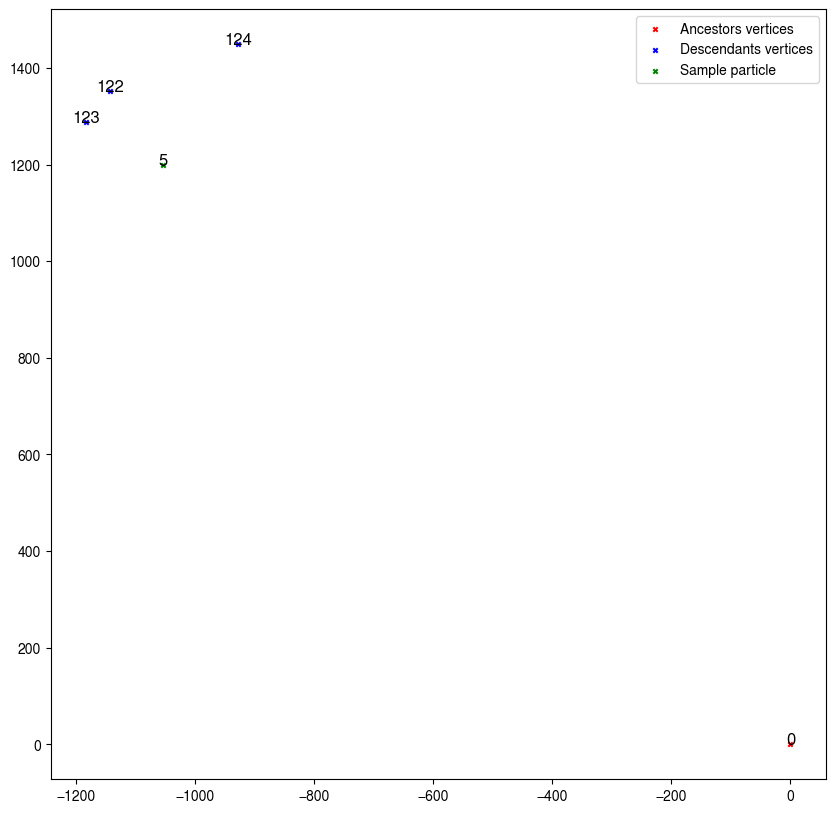

In [96]:
medium_sample_particle = 5
medium_descendants = list(nx.descendants(medium_G, medium_sample_particle))
medium_ancestors = list(nx.ancestors(medium_G, medium_sample_particle))

plt.figure(figsize=(10, 10))
plt.scatter(ODD_medium_particles_df.loc[medium_ancestors].vz, ODD_medium_particles_df.loc[medium_ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(ODD_medium_particles_df.loc[medium_descendants].vz, ODD_medium_particles_df.loc[medium_descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(ODD_medium_particles_df.loc[medium_sample_particle].vz, ODD_medium_particles_df.loc[medium_sample_particle].vr, c="green", s=10, marker="x", label="Sample particle")

# Add text with the particle ID
plt.text(ODD_medium_particles_df.loc[medium_sample_particle].vz, ODD_medium_particles_df.loc[medium_sample_particle].vr, f"{medium_sample_particle}", fontsize=12, ha='center')

for ancestor in medium_ancestors:
    plt.text(ODD_medium_particles_df.loc[ancestor].vz, ODD_medium_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in medium_descendants:
    plt.text(ODD_medium_particles_df.loc[descendant].vz, ODD_medium_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')

plt.legend()
plt.show()


## Comprehensive Study

1. Start from the primary pion in the keep_all event
2. Look at immediate daughters
3. For each daughter, match a particle in the low_threshold event
4. If there is no match, add that non-matching daughter to the non-matching list

## Some Questions...

1. Are there virtual particles in the tracker between, e.g. a primary, and a decay product that leaves a hit?

In [ ]:
# Want to get a particle that starts and ends in the tracker, which doesn't leave a hit, but has a decay product that does.

In [ ]:
full_tracker_df

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,r,R,phi,theta,eta,pt,detector
0,70438988367857670,5.965323,1.323336,0,-32.387418,1.662442,-403.378270,-0.327436,0.026107,-3.389788,0.000621,8352,32.430056,404.679796,3.090308,3.061369,-3.215548,0.328476,PixelBarrelReadout
1,12472937214974998,5.850329,0.600617,0,48.633578,-47.682691,-363.285304,0.021487,-0.041030,-0.198755,0.000209,11871,68.109206,369.614767,-0.775526,2.956263,-2.375897,0.046315,PixelBarrelReadout
2,10167862626950422,5.872139,0.568466,0,54.373627,-42.464137,-369.909179,0.138421,-0.088689,-0.723106,0.000167,11870,68.990537,376.287782,-0.663029,2.957204,-2.381020,0.164396,PixelBarrelReadout
3,65108912478751750,5.773998,1.102025,0,2.459692,-31.890374,-346.003253,0.030565,-0.490668,-4.293781,0.000387,8350,31.985091,347.478485,-1.493819,3.049413,-3.076455,0.491619,PixelBarrelReadout
4,67660045743228678,5.510508,0.788981,0,-31.236043,6.956853,-266.608993,-0.351317,0.089458,-2.260428,0.000236,8347,32.001378,268.522706,2.922451,3.022133,-2.816734,0.362528,PixelBarrelReadout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21548,16329466777950,21.203285,0.041919,0,-600.486383,712.145458,3009.437093,-0.000046,-0.000026,-0.000127,0.000069,4420523,931.522973,3150.308979,2.271334,0.300180,1.888970,0.000052,LongStripEndcapReadout
21549,15749646188894,20.597553,0.124870,0,-454.044896,916.336486,3020.376044,0.000130,-0.000416,-0.000175,0.000041,4420748,1022.657970,3188.808675,2.030838,0.326471,1.803625,0.000435,LongStripEndcapReadout
21550,16333760692558,22.928253,0.125527,0,-462.682351,888.891570,2625.625000,-0.000365,0.000189,0.000105,0.000149,4420748,1002.099387,2810.357597,2.050722,0.364598,1.690943,0.000411,LongStripEndcapReadout
21551,1554779373662,26.342630,0.032734,0,463.756306,-695.160774,2990.604977,0.000071,-0.000099,-0.000032,0.000058,4421240,835.654482,3105.162885,-0.982479,0.272477,1.987135,0.000121,LongStripEndcapReadout


In [ ]:
full_particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi', 'vr', 'endpoint_r',
       'created_in_simulation', 'created_inside_tracker',
       'ended_inside_tracker', 'backscatter', 'left_tracker_hit'],
      dtype='object')

In [ ]:
full_particles_df["left_tracker_hit"] = full_particles_df.index.isin(full_tracker_df.particle_id)

In [ ]:
particles_without_hit_with_daughters_mask = ~full_particles_df.left_tracker_hit & (full_particles_df.daughters_begin != full_particles_df.daughters_end) & full_particles_df.created_inside_tracker & full_particles_df.ended_inside_tracker
particles_without_hit_with_daughters = full_particles_df[particles_without_hit_with_daughters_mask]

In [ ]:
particles_without_hit_with_daughters

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter,left_tracker_hit
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,6999.999937,inf,0.000000,0.000000,0.006807,0,1,1,False,False
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,2607.457556,7.572637,-0.084146,0.006807,0.006807,0,1,1,False,False
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,376.885189,7.320521,-1.804631,0.006807,0.006807,0,1,1,False,False
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,267.841489,5.740426,-1.800382,0.006807,0.006807,0,1,1,False,False
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,155.382063,4.531422,0.143721,0.006807,0.006807,0,1,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4418820,11,0,1493172224,-1.000000,11.084579,0.000511,-62.257651,328.841160,727.038321,-0.000802,...,0.001803,1.294607,-2.631118,334.682721,334.322265,1,1,1,False,False
4418824,11,0,1493172224,-1.000000,12.360787,0.000511,-110.987173,463.293311,1081.869257,0.000015,...,0.000099,-0.233530,1.417352,476.401978,476.497433,1,1,1,False,False
4418828,11,0,1493172224,-1.000000,13.297421,0.000511,-155.822986,557.987815,1342.374586,-0.000048,...,0.000082,0.257100,-2.214237,579.336866,579.151288,1,1,1,False,False
4420910,11,0,1493172224,-1.000000,23.442286,0.000511,-452.661192,909.383341,2682.700587,0.000087,...,0.000105,0.425643,-0.429950,1015.815049,1015.764855,1,1,1,False,False


In [ ]:
# sample = 4

for sample in particles_without_hit_with_daughters.index:
    daughters_indices = full_daughters_df[full_particles_df.loc[sample].daughters_begin:full_particles_df.loc[sample].daughters_end]
    daughters = full_particles_df.loc[daughters_indices.particle_id]
    
    parents_indices = full_parents_df[full_particles_df.loc[sample].parents_begin:full_particles_df.loc[sample].parents_end]
    parents = full_particles_df.loc[parents_indices.particle_id]
    
    # if daughters.left_tracker_hit.any() and full_particles_df.loc[sample].simulatorStatus != 0:
    #     break

    if daughters.left_tracker_hit.any() and full_particles_df.loc[sample].simulatorStatus != 0 and parents.left_tracker_hit.any():
        print("Found one!")
        break

Found one!


In [ ]:
sample

45391

In [ ]:
full_particles_df.loc[sample]

PDG                                22
generatorStatus                     0
simulatorStatus            1493172224
charge                            0.0
time                        12.313094
mass                              0.0
vx                        -846.548213
vy                        -306.247474
vz                        1889.617731
px                          -0.000096
py                          -0.000026
pz                           0.000134
endpoint_x                -110.407437
endpoint_y                 174.623777
endpoint_z                  1636.9633
parents_begin                   64851
parents_end                     64852
daughters_begin                153217
daughters_end                  153221
pt                           0.000099
p                            0.000167
eta                          1.109493
phi                         -2.871624
vr                         900.239631
endpoint_r                 206.599288
created_in_simulation               1
created_insi

In [ ]:
daughters

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter,left_tracker_hit
45636,11,0,1493172224,-1.0,12.395187,0.000511,-860.656302,-310.151519,1909.402080,-0.000205,...,0.000236,0.482254,-2.906833,914.835087,914.842236,1,1,1,False,True
45637,11,0,1493172224,-1.0,13.088897,0.000511,-663.332557,-269.445030,1960.951589,0.000033,...,0.000089,1.158479,-0.862584,715.968369,715.968346,1,1,1,False,False
45638,11,0,1493172224,-1.0,15.689675,0.000511,-111.131797,175.335553,1636.657297,0.000016,...,0.000140,-0.549036,1.441764,207.588132,207.588300,1,1,1,False,False
45639,11,0,1224736768,-1.0,15.693213,0.000511,-110.407437,174.623777,1636.963300,0.000056,...,0.000296,1.306370,1.189063,206.599288,206.600163,1,1,1,False,False


In [ ]:
full_particles_df.loc[32]

PDG                                1
generatorStatus                   41
simulatorStatus                    0
charge                     -0.333333
time                        8.091558
mass                             0.0
vx                          0.003543
vy                         -0.005813
vz                       -105.372111
px                              -0.0
py                               0.0
pz                        155.361861
endpoint_x                  0.003543
endpoint_y                 -0.005813
endpoint_z               -105.372111
parents_begin                     30
parents_end                       31
daughters_begin                   58
daughters_end                     60
pt                               0.0
p                         155.361861
eta                        42.822278
phi                         2.356194
vr                          0.006807
endpoint_r                  0.006807
created_in_simulation              0
created_inside_tracker             1
e

In [ ]:
ancestors = list(nx.ancestors(G, sample))
descendants = list(nx.descendants(G, sample))

In [ ]:
ancestors

[np.int64(8291),
 np.int64(8294),
 np.int64(44873),
 np.int64(45388),
 np.int64(8366),
 np.int64(45390),
 np.int64(8279),
 np.int64(8312),
 np.int64(8281),
 np.int64(8282),
 np.int64(8280),
 np.int64(8284),
 np.int64(8287),
 np.int64(44895)]

In [ ]:
descendants

[np.int64(45636), np.int64(45637), np.int64(45638), np.int64(45639)]

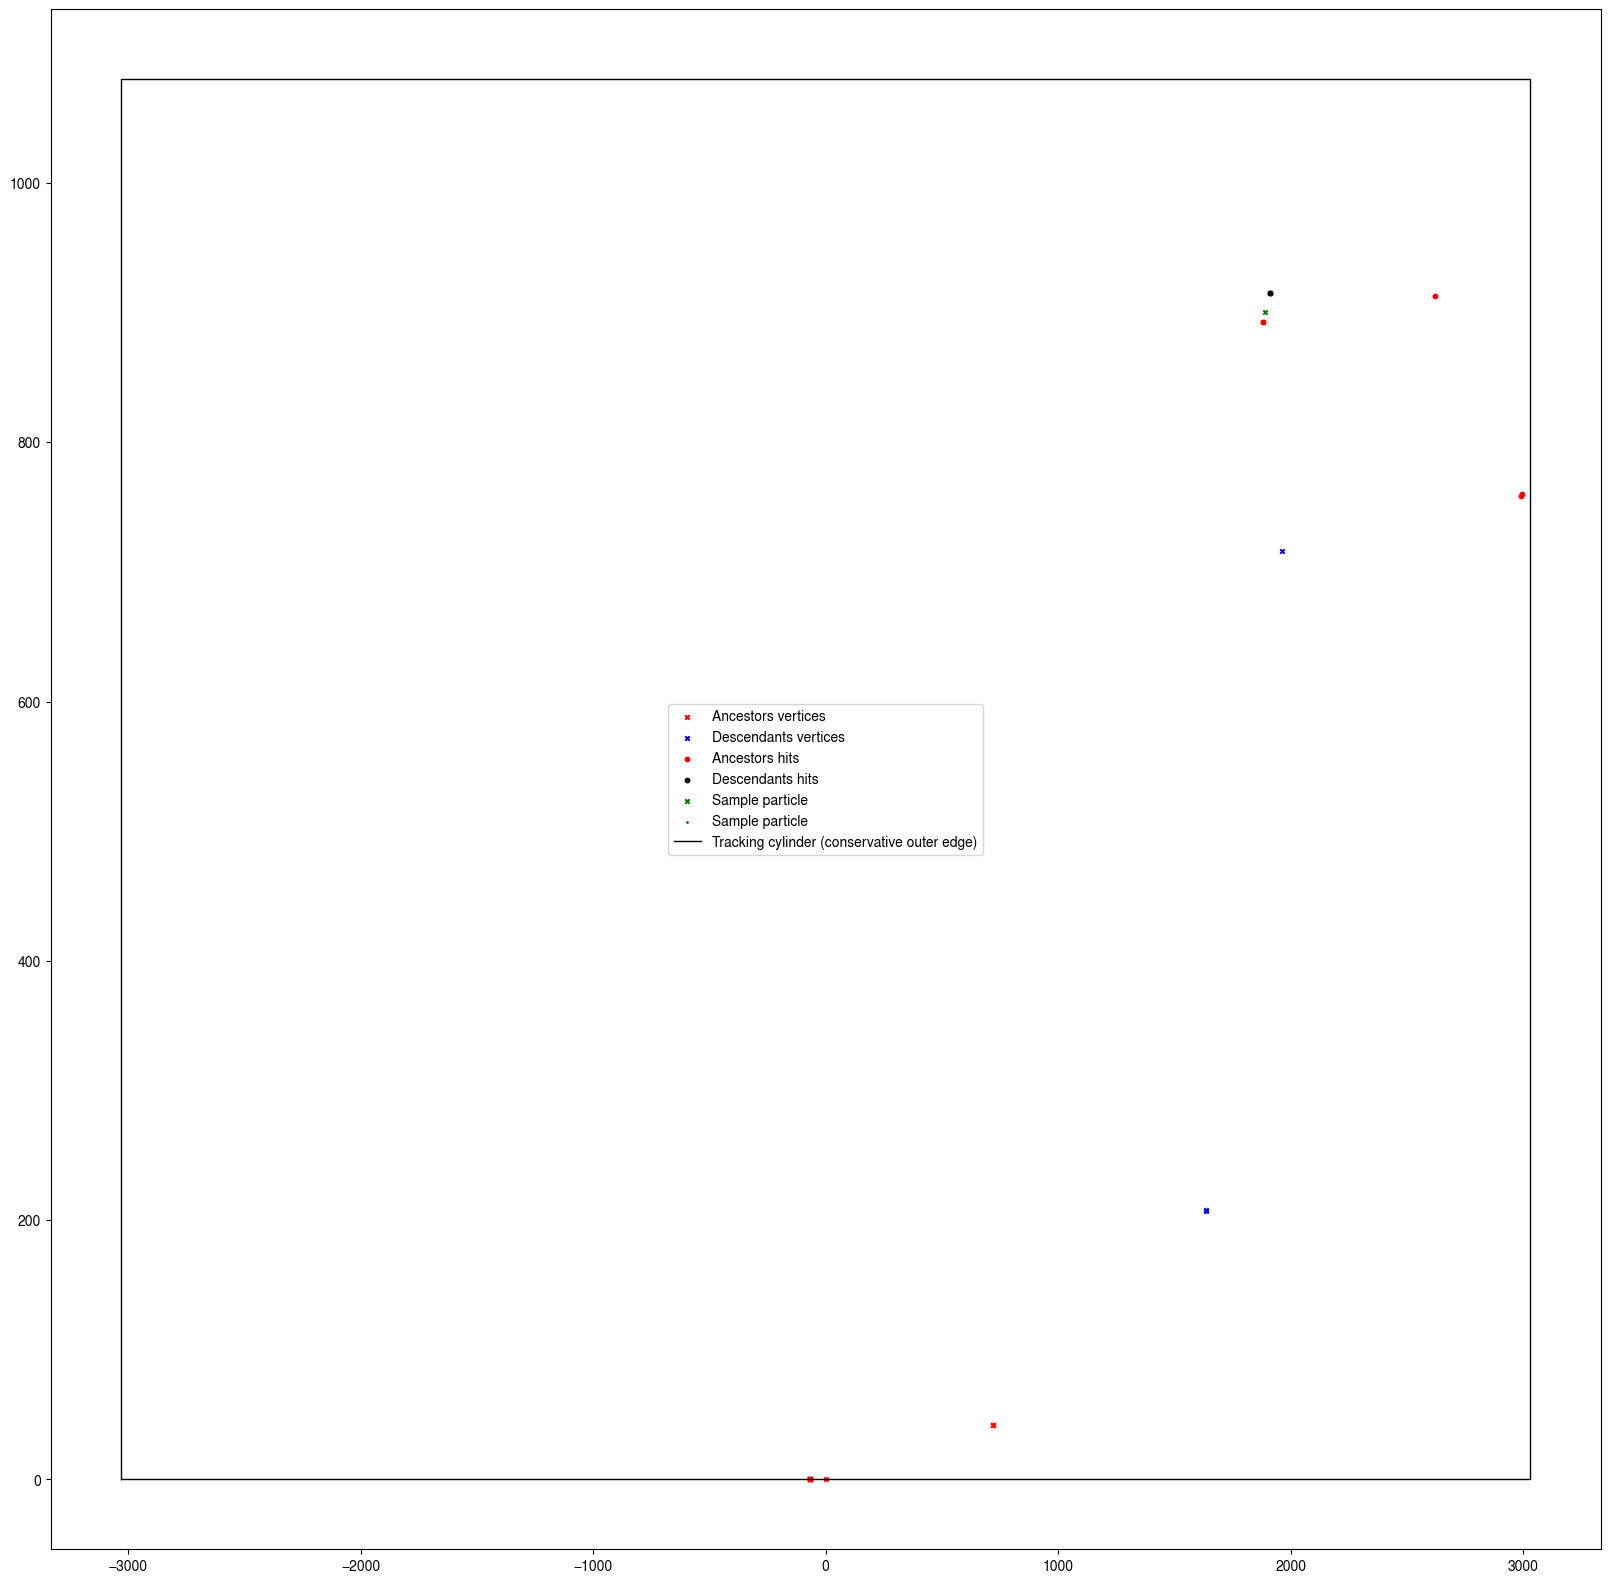

In [ ]:
plt.figure(figsize=(20, 20))
plt.scatter(full_particles_df.loc[ancestors].vz, full_particles_df.loc[ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(full_particles_df.loc[descendants].vz, full_particles_df.loc[descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")

plt.scatter(full_tracker_df[full_tracker_df.particle_id.isin(ancestors)].z, full_tracker_df[full_tracker_df.particle_id.isin(ancestors)].r, c="red", s=10, label="Ancestors hits")
plt.scatter(full_tracker_df[full_tracker_df.particle_id.isin(descendants)].z, full_tracker_df[full_tracker_df.particle_id.isin(descendants)].r, c="black", s=10, label="Descendants hits")

plt.scatter(full_particles_df.loc[sample].vz, full_particles_df.loc[sample].vr, c="green", s=10, marker="x", label="Sample particle")
plt.scatter(full_tracker_df[full_tracker_df.particle_id == sample].z, full_tracker_df[full_tracker_df.particle_id == sample].r, c="green", s=1, label="Sample particle")

# add tracker boundaries
tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']
plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
    

plt.legend()
plt.show()
